In [56]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split


In [57]:
def build_float_to_boolean_encoder():
    # 1) Input layer for two float inputs
    input_layer = tf.keras.Input(shape=(2,), name="float_input")  # Shape (batch_size, 2)

    # Create a normalization layer
    norm = layers.Normalization(axis=-1)
   
    x = norm(input_layer)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # 20% dropout for regularization
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.1)(x)  # another dropout
    x = layers.Dense(8, activation='relu')(x)
    x = layers.Dropout(0.1)(x) 

    outputs = layers.Dense(3, activation='sigmoid')(x)

    model = Model(inputs=input_layer, outputs=outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        #metrics=['accuracy']  
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
            tf.keras.metrics.AUC(name='auc')
        ]
        # Tracks the accuracy of individual bits (0/1)
    )

    # Return both the model and the normalization layer (we'll adapt it later)
    return model, norm



In [58]:
# Path to the folder containing the CSV files
def readDatasInPanda(file_paths):
#we probaply should not combine all the files in one dataset just now for testing
    folder_path = 'data'
    dataframes = []
    for file_path in file_paths: 
        print("read: " + file_path)
        df = pd.read_csv(file_path)
        
        # Append the cleaned DataFrame to the list
        dataframes.append(df)

# Combine all DataFrames into one
        pandas_data = pd.concat(dataframes, ignore_index=True)

# Display the first few rows of the combined DataFrame
    return pandas_data

In [59]:
#df = readDatasInPanda(["./data/Circuit_Scenario4_res.csv", "./data/Circuit_Scenario5_res.csv", "./data/Circuit_Scenario6_res.csv", "./data/Circuit_Scenario7_res.csv",
#                      "./data/Circuit_Scenario8_res.csv"])
df = readDatasInPanda(["./data/Circuit_ScenarioDataGeneration_res.csv"])

read: ./data/Circuit_ScenarioDataGeneration_res.csv


In [60]:
y = df[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X = df[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
Y_binary = y - 1.0

#X

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_2 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_9 (Dense)             (None, 64)                192       
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dropout_8 (Dropout)         (None, 32)                0         
                                                           

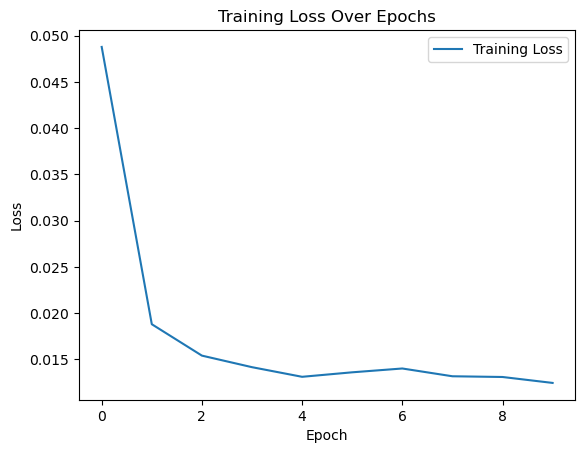

In [61]:
model, norm_layer = build_float_to_boolean_encoder()


    # We must "adapt" the normalization layer on our training data
norm_layer.adapt(X)

    # Print a summary
model.summary()

    # Train/fit the model
history = model.fit(
    X, 
    Y_binary, 
    epochs=10,        # Feel free to increase epochs
    batch_size=4,
    verbose=1
)

    # Optional: Plot the training loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

   

In [62]:
single_input = X[190]  # This is a single value, shape = (1,)

# Reshape to add batch dimension
single_input = single_input.reshape(1, -1)  # Shape = (1, 1)

# Predict for the single input
single_pred = model.predict(single_input)
preds_binary = (single_pred > 0.5).astype(int)
print("Raw Prediction:", preds_binary)


1/1 [==============================] - 0s 57ms/step
Raw Prediction: [[1 0 0]]


In [63]:
X #= X.reshape(-1, 1)
preds_raw = model.predict(X)  # shape = (num_samples, 3)
    # Threshold at 0.5 => 0 or 1
X
#preds_raw

2188/2188 [==============================] - 1s 500us/step


array([[  4.76190567,   5.        ],
       [  4.76190567,   5.        ],
       [  4.76190567,   5.        ],
       ...,
       [ 90.90909132, 500.        ],
       [ 13.04347826,   5.        ],
       [ 13.04347826,   5.        ]])

In [64]:
#predict faults. 
#Circuit_ScenarioDescend_res
#Circuit_ScenarioVoltageSwitch_res
df_d = readDatasInPanda(["./data/Circuit_ScenarioVoltageSwitch_res.csv"])
#df_d

read: ./data/Circuit_ScenarioVoltageSwitch_res.csv


In [65]:
y_d = df_d[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values
# Convert output column to float as well:
X_d = df_d[["circ1.r_load.v", "circ1.r_load.r_int"]].astype(float).values
#X_d = df_d[["circ1.r_load.v"]].astype(float).values
Y_binary_d = y_d - 1.0
#X_d

In [66]:
#X_d = X_d.reshape(-1, 1)
preds_raw_d = model.predict(X_d)
preds_binary_d = (preds_raw_d > 0.5).astype(int)

preds_binary_d
#Y_binary_d
for real, preds in zip(Y_binary_d, preds_binary_d):
    print(f"Real: {real} | Predictions: {preds}")
X_d


3/3 [==============================] - 0s 0s/step
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 0. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions: [1 1 1]
Real: [1. 1. 0.] | Predictions

array([[ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 71.42859694, 100.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75000732,  75.        ],
       [ 93.75      ,  50.        ],
 

In [67]:
#Compare prediction with fact 
#for elem in preds_binary_d:
#    print(preds_binary_d)

model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 float_input (InputLayer)    [(None, 2)]               0         
                                                                 
 normalization_2 (Normalizat  (None, 2)                5         
 ion)                                                            
                                                                 
 dense_9 (Dense)             (None, 64)                192       
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_10 (Dense)            (None, 32)                2080      
                                                                 
 dropout_8 (Dropout)         (None, 32)                0         
                                                           

In [68]:
def isAnomolouys(df_data): 
    anomolous = []
    for idx, row in df_data.iterrows():
        #print(row)
        # Check any of the specified columns for value == 2
        if (row["circ1.bats[1].state"] == 2 or
            row["circ1.bats[2].state"] == 2 or
            row["circ1.bats[3].state"] == 2 or
            row["circ1.s[1].state"]  == 2 or
            row["circ1.s[2].state"]  == 2 or
            row["circ1.s[3].state"]  == 2):
            anomolous.append(True)
        else:
            anomolous.append(False)
    return anomolous
    



In [69]:
#Test 
df_d = readDatasInPanda(["./data/Circuit_ScenarioVoltageSwitch_res.csv"])

y_d = df_d[["circ1.s[1].mode", "circ1.s[2].mode", "circ1.s[3].mode"]].astype(float).values

# Convert output column to float as well:
X_d = df_d[["circ1.r_load.v",  "circ1.r_load.r_int"]].astype(float).values
#X_d = df_d[["circ1.r_load.v"]].astype(float).values
Y_binary_d = y_d - 1.0
#X_d
#X_d = X_d.reshape(-1, 1)
preds_raw_d = model.predict(X_d)
preds_binary_d = (preds_raw_d > 0.5).astype(int)

preds_binary_d




read: ./data/Circuit_ScenarioVoltageSwitch_res.csv
3/3 [==============================] - 0s 4ms/step


array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 1],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1, 1, 0],
       [1,

In [70]:
anomolous = isAnomolouys(df_d)
#print(anomolous)
#Y_binary_d
for real, preds, anom in zip(Y_binary_d, preds_binary_d, anomolous):
    mismatch = (
        int(real[0]) != int(preds[0]) or
        int(real[1]) != int(preds[1]) or
        int(real[2]) != int(preds[2])
    )
   
   # if mismatch:
        #
     #   if anom == False:
         #   print(mismatch)
        #    print("Error False")
       #     print(f"Real: {real} | Predictions: {preds} | anom: {anom}")
   # else: 
     #   if anom == True:
      #      print(mismatch)
     #       print("Error True")
    #        print(f"Real: {real} | Predictions: {preds} | anom: {anom}")

    print(f"Real: {real} | Predictions: {preds} | anom: {anom}")


Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 0. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 1. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 1. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 1. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 1. 0.] | Predictions: [1 1 1] | anom: False
Real: [1. 1. 0.] | Predictio

In [1]:
X_test = df_d[["circ1.r_load.v", "circ1.r_load.i"]].astype(float).values

# Let's define normal vs. anomaly using your mask
normal_mask = ~anomaly_mask        # Invert the boolean mask for normals
anomaly_data = X_test[anomaly_mask]
normal_data  = X_test[normal_mask]

plt.figure(figsize=(8,6))

# Plot normal samples in one color
plt.scatter(
    normal_data[:, 0], 
    normal_data[:, 1], 
    alpha=0.7, 
    label='Normal'
)

# Plot anomalous samples in another color (e.g., red)
plt.scatter(
    anomaly_data[:, 0], 
    anomaly_data[:, 1], 
    alpha=0.7, 
    color='red', 
    label='Anomalous'
)

plt.xlabel("Voltage (circ1.r_load.v)")
plt.ylabel("Current (circ1.r_load.i)")
plt.title("Voltage vs. Current (Anomalies in Red)")
plt.legend()
plt.show()

NameError: name 'df_d' is not defined